# Multipartition results with BDA

I will fill in the specific details in due time

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import logging, sys
import math

from radioimaging.util import util
from radioimaging.evaluation import evaluation

matplotlib.rcParams['figure.figsize'] = [6, 5]

cmap = "turbo"

breakdowns = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "other"
]

breakdowns_parallel = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "wait",
    "other"
]

num_mc_l1 = 5
num_mc_msc = 10

def total_timings(timings, breakdowns):
    total = []
    
    for i, breakdown in enumerate(breakdowns):
        curr_timing = 0

        for timing in timings:
            curr_timing += timing[i]

        total.append(curr_timing)
        
    return total

pcols = ["forestgreen", "teal", "mediumblue", "blueviolet", "fuchsia"]

/usr/lib/python3.10/abc.py:106: FutureWarning: xarray subclass Visibility should explicitly define __slots__
  cls = super().__new__(mcls, name, bases, namespace, **kwargs)


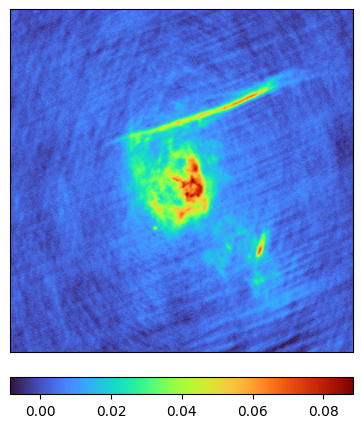

In [2]:
sgrc_res_path = "../results/multi_partition_bda_results/SGRC_MID_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<20", "18-36", "35-57", "55-88", ">86"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgrc_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgrc_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgrc_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

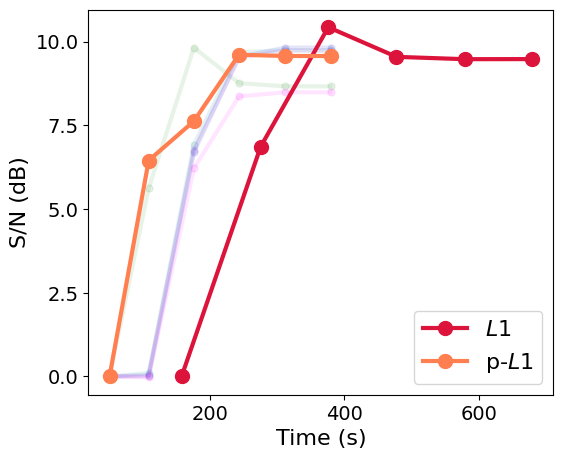

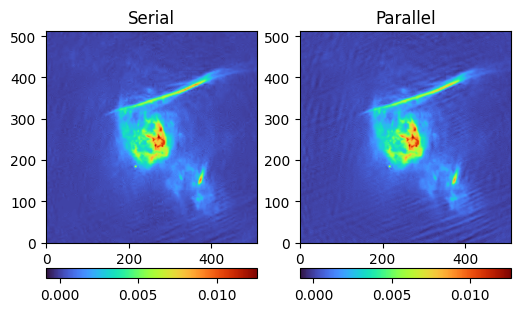

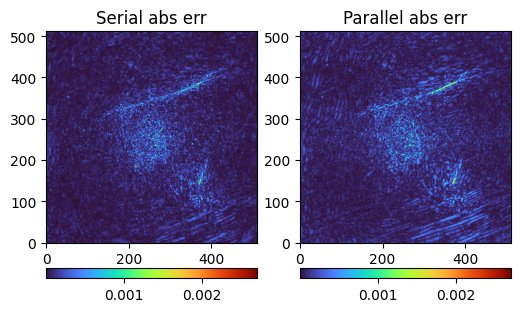

In [3]:
serial_times_sep = util.read_csv(sgrc_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgrc_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRC_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgrc_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgrc_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgrc_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=True, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=True, cmap=cmap)

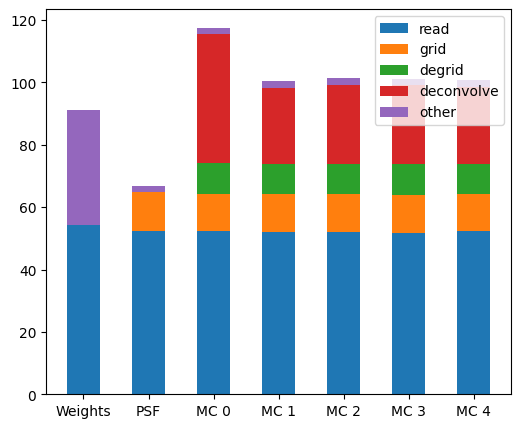

In [4]:
#Serial l1

for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

average_deconv = 0

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
sgrc_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

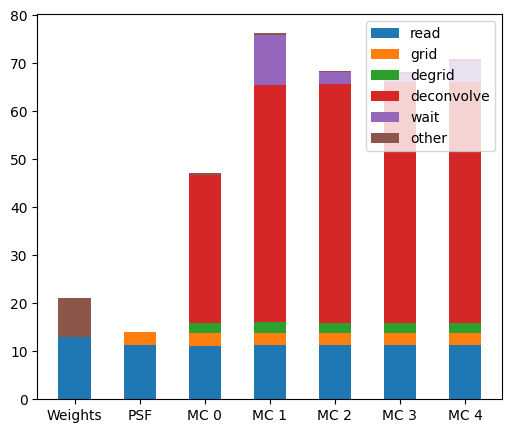

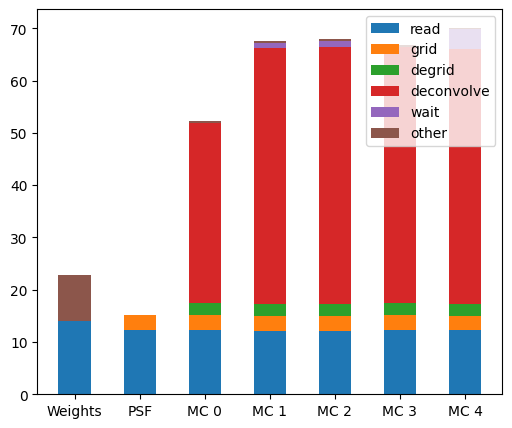

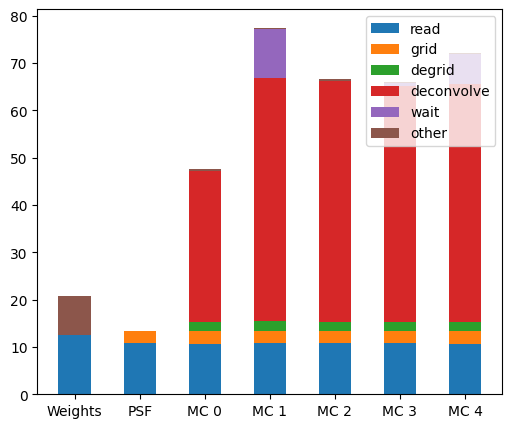

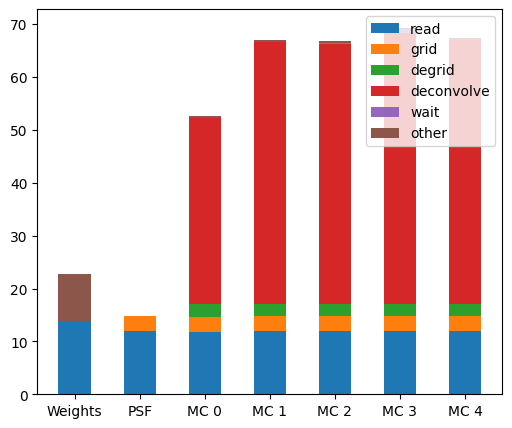

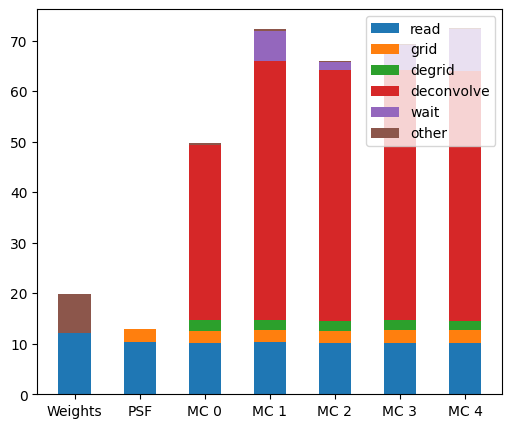

In [5]:
#Parallel l1

sgrc_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgrc_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## And for a (much) larger DB (SKA MID)

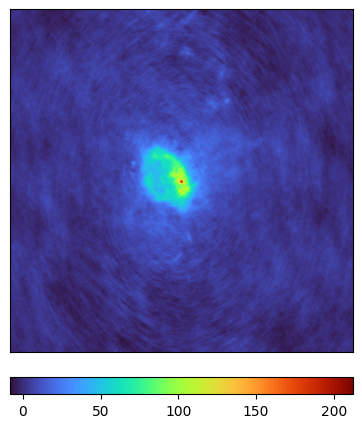

In [6]:
sgra_res_path = "../results/multi_partition_bda_results/SGRA_full_averaged_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<15", "13-28", "26-49", "47-87", ">85"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgra_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgra_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgra_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

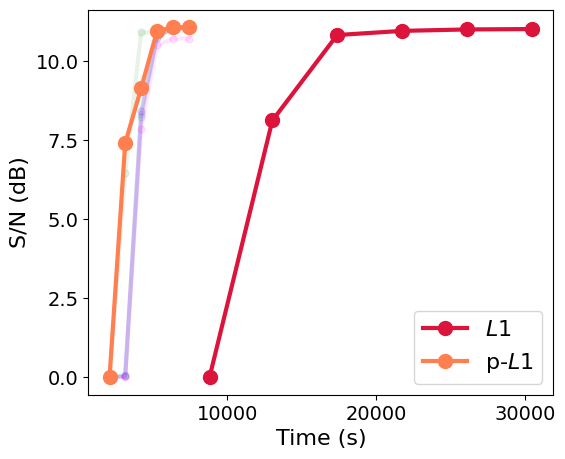

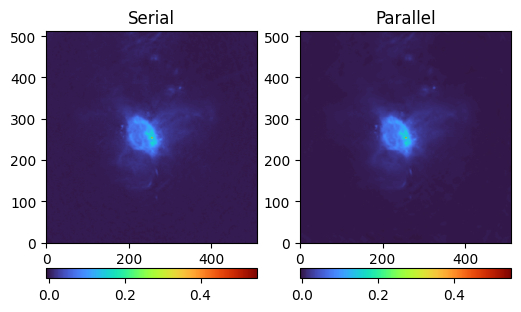

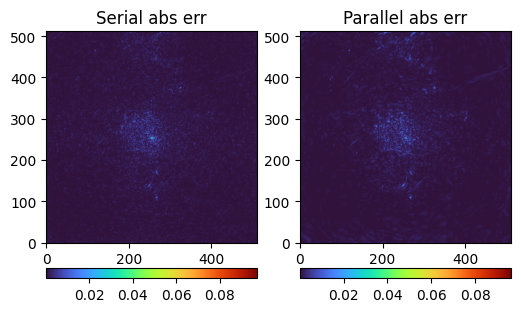

In [7]:
serial_times_sep = util.read_csv(sgra_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgra_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRA_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgra_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgra_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgra_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=False, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=False, cmap=cmap)

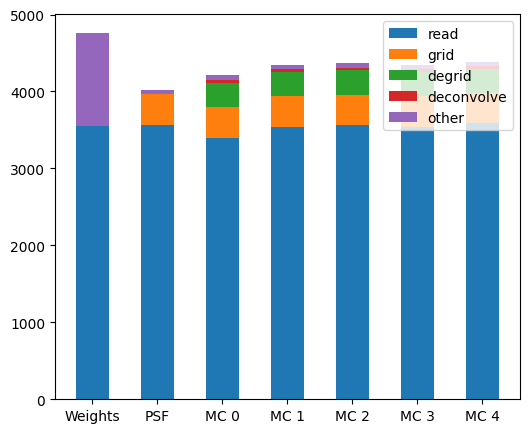

In [8]:
#Serial l1

for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

average_deconv = 0

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
sgra_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

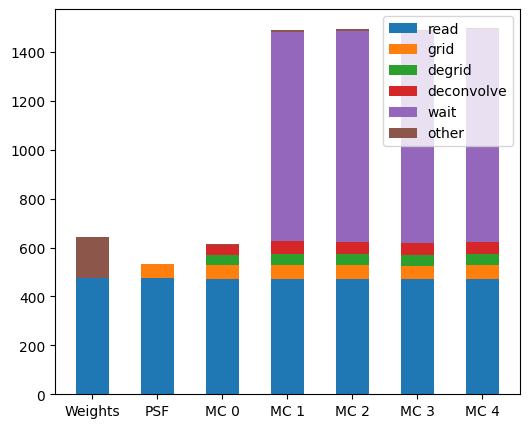

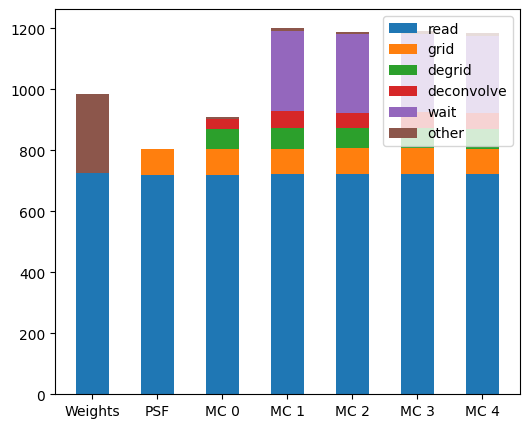

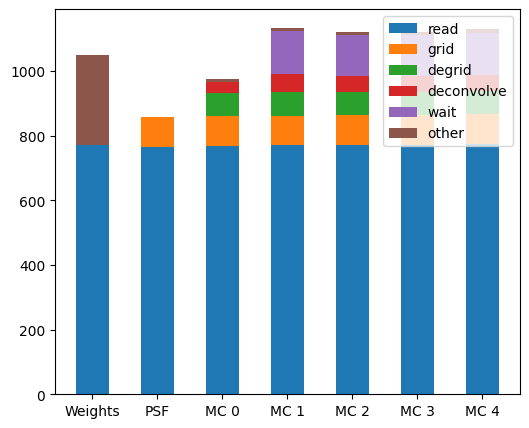

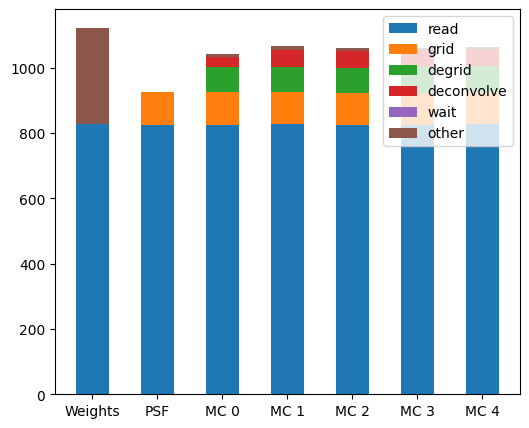

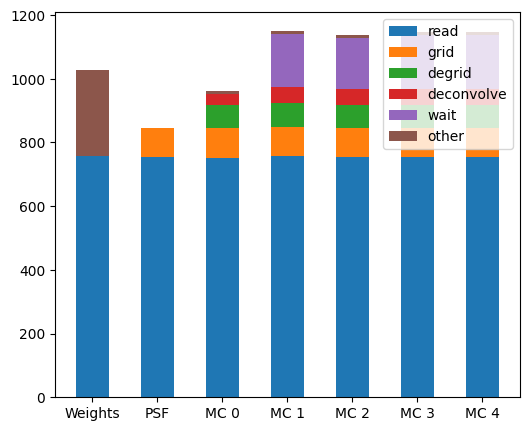

In [9]:
#Parallel l1

sgra_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgra_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## And for SKA-LOW with a large DB

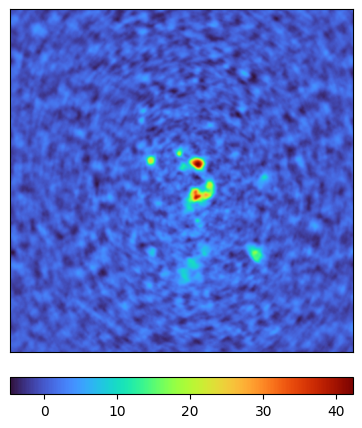

In [16]:
sgrb_res_path = "../results/multi_partition_bda_results/SGRB_full_averaged_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<35", "33-54", "52-73", "72-97", ">95"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgrb_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgrb_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgrb_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

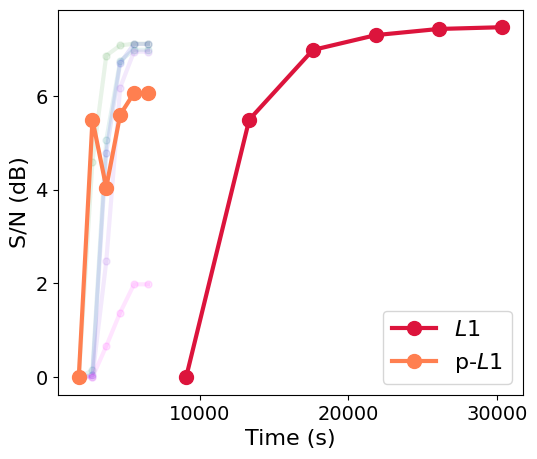

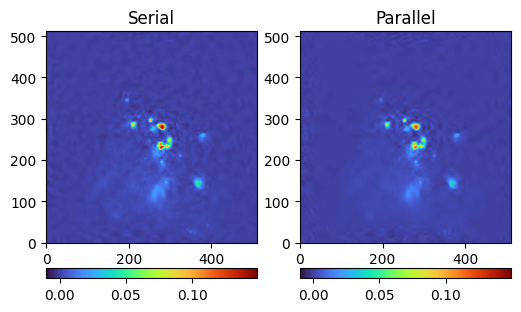

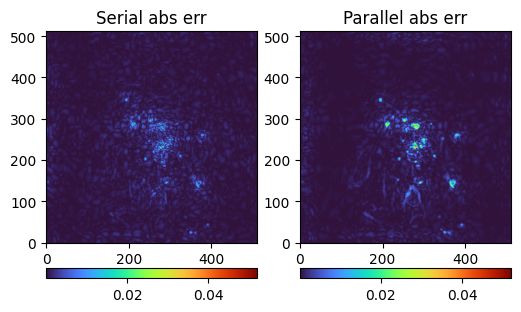

In [20]:
serial_times_sep = util.read_csv(sgrb_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgrb_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRB_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgrb_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if True: #best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgrb_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgrb_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if True: #best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=True, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=True, cmap=cmap)

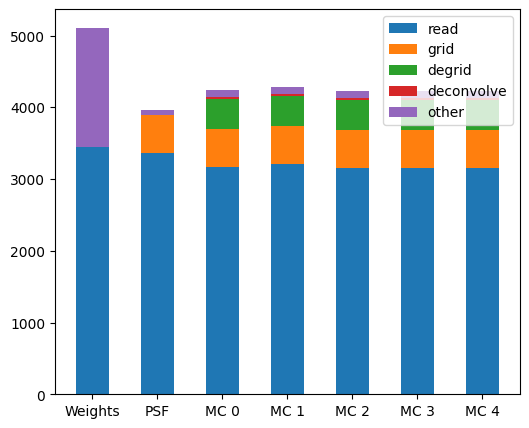

In [21]:
#Serial l1

for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

average_deconv = 0

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
sgrb_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

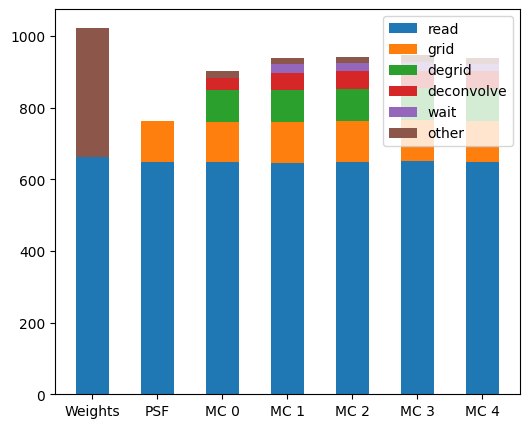

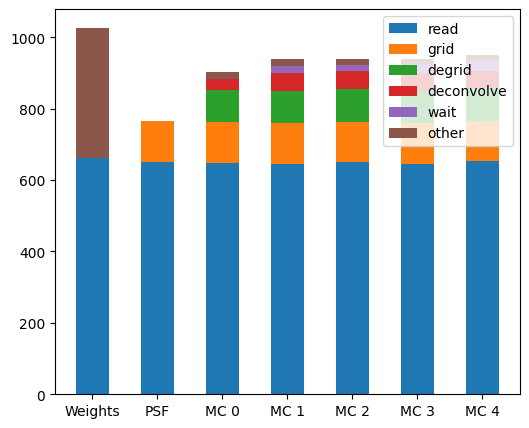

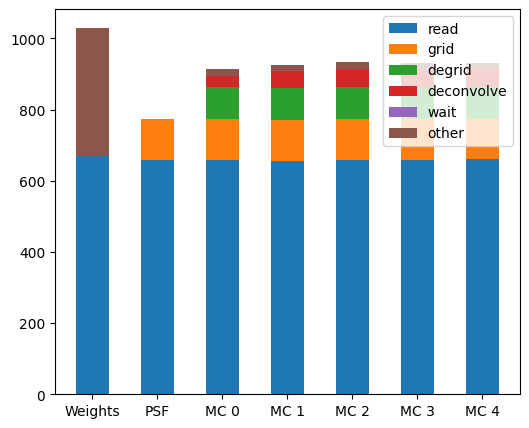

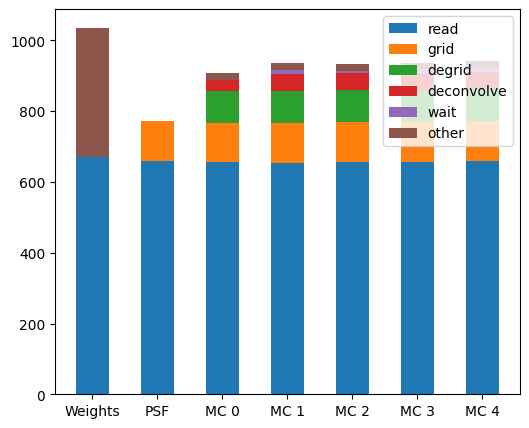

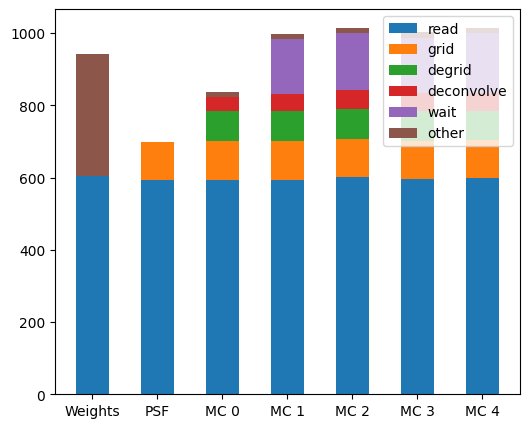

In [22]:
#Parallel l1

sgrb_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgrb_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()